In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("../dataset/train.csv")
df.head()

/tmp/ipykernel_10417/1562469212.py:1: DtypeWarning: Columns (0: PRN, 1: Carrier_Doppler_hz, 2: Pseudorange_m, 3: RX_time, 4: TOW, 5: Carrier_phase, 6: EC, 7: LC, 8: PC, 9: PIP, 10: PQP, 11: TCD, 12: CN0) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("../dataset/train.csv")


,time,channel,PRN,Carrier_Doppler_hz,Pseudorange_m,RX_time,TOW,Carrier_phase,EC,LC,PC,PIP,PQP,TCD,CN0,spoofed
0,0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,ch0,0
1,0,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,ch1,0
2,0,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,ch2,0
3,0,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,ch3,0
4,0,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,ch4,0


In [3]:
cols=[]
for col in df.columns:
    if df[col].dtype == "object":
        print(col)
        cols.append(col)

PRN
Carrier_Doppler_hz
Pseudorange_m
RX_time
TOW
Carrier_phase
EC
LC
PC
PIP
PQP
TCD
CN0


In [4]:
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [6]:
df.fillna(0,inplace=True)

,time,channel,PRN,Carrier_Doppler_hz,Pseudorange_m,RX_time,TOW,Carrier_phase,EC,LC,PC,PIP,PQP,TCD,CN0,spoofed
0,0,ch0,0.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
1,0,ch1,0.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
2,0,ch2,0.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
3,0,ch3,0.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
4,0,ch4,0.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891211,111401,ch3,26.0,-2113.491414,5.482363e+06,263154.8,263154.781713,193060.427210,101265.445312,96612.585938,104833.250000,-104328.625000,-10273.680664,-2108.602539,42.208794,0
891212,111401,ch4,4.0,-493.836685,2.666525e+06,263154.8,263154.791105,48193.433748,112036.953125,122600.250000,124538.890625,124537.945312,-485.292389,-495.879303,43.671265,0
891213,111401,ch5,0.0,0.000000,0.000000e+00,263154.8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
891214,111401,ch6,0.0,0.000000,0.000000e+00,263154.8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0


In [7]:
df=df.sort_values("time")

In [9]:
df.head(8)

,time,channel,PRN,Carrier_Doppler_hz,Pseudorange_m,RX_time,TOW,Carrier_phase,EC,LC,PC,PIP,PQP,TCD,CN0,spoofed
0,0,ch0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0,ch1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0,ch2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0,ch3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0,ch4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,0,ch5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,0,ch6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7,0,ch7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [10]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset,ConcatDataset
import numpy as np
import pandas as pd

In [ ]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class CrudeDataset(Dataset):

    mapping = {f"ch{i}": i for i in range(8)}
    feature_columns = ['PRN', 'Carrier_Doppler_hz', 'Pseudorange_m', 'RX_time', 
                        'TOW', 'Carrier_phase', 'EC', 'LC', 'PC', 'PIP', 'PQP', 
                        'TCD', 'CN0']

    def __init__(self, df, seq_len=15, target_time_series):
        self.df = df

        # Ensure correct types early - keep as int for sorting
        self.df["channel"] = self.df["channel"].map(CrudeDataset.mapping)
        self.df["channel"] = self.df["channel"].astype(int)  # Changed to int

        # Get unique times for indexing
        self.unique_times = sorted(target_time_series)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.unique_times) 

    def __getitem__(self, idx):
        # Get time windows using unique times
        start_time = self.unique_times[idx-self.seq_len]
        end_time = self.unique_times[idx]
        
        # Get all data for the time window
        time_window_times = self.unique_times[idx-self.seq_len:idx]
        
        # Get target from the last timestep
        target_time = time_window_times[-1]
        target_data = self.df[self.df["time"] == target_time]
        target_label = target_data["spoofed"].values.mean()  # Use mean instead of sum/len
        target_features = self.flatten_single_timestep(target_data)
        
        # Collect features for all timesteps in the window
        features = []
        for t in time_window_times:
            time_data = self.df[self.df["time"] == t]
            single_timestep_features = self.flatten_single_timestep(time_data)
            features.append(single_timestep_features)
        
        # Convert to tensors
        features = torch.from_numpy(np.array(features)).float()
        target_features = torch.from_numpy(target_features).float()
        target_label = torch.tensor(target_label).float()
        target_time = torch.tensor(target_time).float()
        # Handle numerical issues
        features = torch.nan_to_num(features, nan=0.0, posinf=10.0, neginf=-10.0)
        target_features = torch.nan_to_num(target_features, nan=0.0, posinf=10.0, neginf=-10.0)
        
        # Clamp to stable range
        features = torch.clamp(features, -5.0, 5.0)
        target_features = torch.clamp(target_features, -5.0, 5.0)
        
        return target_label, features, target_features,target_time
    
    def flatten_single_timestep(self, time_data):
        """
        Flatten a single timestep's data (8 channels × 14 features = 112 features)
        """
        # Ensure we have all 8 channels
        if len(time_data) != 8:
            # If missing channels, create a complete dataframe with zeros
            complete_data = []
            for ch in range(8):
                ch_data = time_data[time_data["channel"] == ch]
                if len(ch_data) == 0:
                    # Create zero row for missing channel
                    zero_row = {col: 0 for col in CrudeDataset.feature_columns}
                    zero_row["channel"] = ch
                    complete_data.append(zero_row)
                else:
                    complete_data.append(ch_data.iloc[0].to_dict())
            time_data = pd.DataFrame(complete_data)
        
        # Sort by channel to ensure consistent order
        time_data_sorted = time_data.sort_values('channel')
        
        # Flatten all features for all 8 channels
        flattened = time_data_sorted[CrudeDataset.feature_columns].values.flatten()
        
        return flattened  # Shape: (112,)


In [16]:
train_dataset=CrudeDataset(df)

In [17]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

In [18]:
target, features, transformed_target,time = next(iter(train_loader))
print("Target shape:", target.shape)  # (batch_size, 1)
print("Features shape:", features.shape)  # (batch_size, seq_len, num_features)
print("Transformed Target shape:", transformed_target.shape)  # (batch_size, num_features)
print("Target time:", time.shape)

Target shape: torch.Size([32])
Features shape: torch.Size([32, 15, 104])
Transformed Target shape: torch.Size([32, 104])
Target time: torch.Size([32])


In [27]:
df[df["channel"]==0].spoofed.value_counts()

spoofed
0    95486
1    15916
Name: count, dtype: int64

In [28]:
df[df["channel"]==1].spoofed.value_counts()

spoofed
0    95486
1    15916
Name: count, dtype: int64

In [77]:
temp = df[df["channel"]==1]

In [78]:
temp = temp[["time","spoofed"]]

In [79]:
temp.shape

(111402, 2)

In [80]:
from sklearn.model_selection import train_test_split

# Get unique times with their spoofed labels
unique_times = temp.drop_duplicates(subset=['time'])
print(unique_times.shape)
# Split times with stratification
train_times, test_times = train_test_split(
    unique_times['time'].values,
    test_size=0.2,
    stratify=unique_times['spoofed'].values,
    random_state=42
)

# Also split into train/val if needed
train_times, val_times = train_test_split(
    train_times,
    test_size=0.2,
    stratify=unique_times[unique_times['time'].isin(train_times)]['spoofed'].values,
    random_state=42
)

print(f"Train times: {len(train_times)}")
print(f"Val times: {len(val_times)}")
print(f"Test times: {len(test_times)}")

# Verify stratification
print("\nSpoofed distribution in splits:")
train_spoofed = unique_times[unique_times['time'].isin(train_times)]['spoofed'].value_counts(normalize=True)
val_spoofed = unique_times[unique_times['time'].isin(val_times)]['spoofed'].value_counts(normalize=True)
test_spoofed = unique_times[unique_times['time'].isin(test_times)]['spoofed'].value_counts(normalize=True)

print(f"Train: {dict(train_spoofed)}")
print(f"Val: {dict(val_spoofed)}")
print(f"Test: {dict(test_spoofed)}")

(111402, 2)
Train times: 71296
Val times: 17825
Test times: 22281

Spoofed distribution in splits:
Train: {0: np.float64(0.8573552513464991), 1: np.float64(0.1426447486535009)}
Val: {0: np.float64(0.8562131837307153), 1: np.float64(0.14378681626928472)}
Test: {0: np.float64(0.8571428571428571), 1: np.float64(0.14285714285714285)}


In [67]:
train_temp = temp[temp.isin(train_times)]

In [68]:
train_temp = train_temp.dropna()

In [69]:
train_temp.shape

(71296, 2)

In [70]:
train_temp.spoofed.value_counts()

spoofed
0    61126
1    10170
Name: count, dtype: int64

In [85]:
# Filter temp dataframe to keep only rows where time is in train_times
train_temp = temp[temp['time'].isin(train_times)]
val_temp = temp[temp['time'].isin(val_times)]
test_temp = temp[temp['time'].isin(test_times)]

# Verify the split
print(f"Train samples: {len(train_temp)}")
print(f"Val samples: {len(val_temp)}")
print(f"Test samples: {len(test_temp)}")

# Check stratification
print("\nSpoofed distribution:")
print(f"Train: {train_temp['spoofed'].value_counts(normalize=True).to_dict()}")
print(f"Val: {val_temp['spoofed'].value_counts(normalize=True).to_dict()}")
print(f"Test: {test_temp['spoofed'].value_counts(normalize=True).to_dict()}")

Train samples: 71296
Val samples: 17825
Test samples: 22281

Spoofed distribution:
Train: {0: 0.8573552513464991, 1: 0.1426447486535009}
Val: {0: 0.8562131837307153, 1: 0.14378681626928472}
Test: {0: 0.8571428571428571, 1: 0.14285714285714285}


In [ ]:
train_temp.spoofed.value_counts()

spoofed
0    61126
1    10170
Name: count, dtype: int64

In [87]:
val_temp.spoofed.value_counts()

spoofed
0    15262
1     2563
Name: count, dtype: int64

In [89]:
test_temp.spoofed.value_counts()

spoofed
0    19098
1     3183
Name: count, dtype: int64

In [95]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class CrudeDataset(Dataset):

    mapping = {f"ch{i}": i for i in range(8)}
    feature_columns = ['PRN', 'Carrier_Doppler_hz', 'Pseudorange_m', 'RX_time', 
                        'TOW', 'Carrier_phase', 'EC', 'LC', 'PC', 'PIP', 'PQP', 
                        'TCD', 'CN0']

    def __init__(self, df, target_time_series, seq_len=15):
        self.df = df.copy()  # Make a copy to avoid modifying original

        # Ensure correct types early - keep as int for sorting
        self.df["channel"] = self.df["channel"].astype(int)

        # Get unique times for indexing - ensure they're sorted
        self.target_time_series = sorted(target_time_series)
        self.seq_len = seq_len

    def __len__(self):
        # Only return indices that have enough history (seq_len previous timesteps)
        return len(self.target_time_series) - self.seq_len

    def __getitem__(self, idx):
        # idx is offset by seq_len since we need seq_len previous timesteps
        actual_idx = idx + self.seq_len
        
        # Get target time
        target_time = self.target_time_series[actual_idx]
        
        # Get the previous seq_len timesteps
        start_idx = actual_idx - self.seq_len
        
        # Get target from the target timestep
        target_data = self.df[self.df["time"] == target_time]
        target_label = target_data["spoofed"].values.mean()
        target_features = self.flatten_single_timestep(target_data)
        
        # Collect features for all timesteps in the window
        features = []
        for t in range(target_time-self.seq_len,target_time):
            time_data = self.df[self.df["time"] == t]
            single_timestep_features = self.flatten_single_timestep(time_data)
            features.append(single_timestep_features)
        
        # Convert to tensors
        features = torch.from_numpy(np.array(features)).float()
        target_features = torch.from_numpy(target_features).float()
        target_label = torch.tensor(target_label).float()
        target_time_tensor = torch.tensor(target_time).float()
        
        # Handle numerical issues
        features = torch.nan_to_num(features, nan=0.0, posinf=10.0, neginf=-10.0)
        target_features = torch.nan_to_num(target_features, nan=0.0, posinf=10.0, neginf=-10.0)
        
        # Clamp to stable range
        features = torch.clamp(features, -5.0, 5.0)
        target_features = torch.clamp(target_features, -5.0, 5.0)
        
        return target_label, features, target_features, target_time_tensor
    
    def flatten_single_timestep(self, time_data):
        """
        Flatten a single timestep's data (8 channels × 14 features = 112 features)
        """
        # Ensure we have all 8 channels
        if len(time_data) != 8:
            # If missing channels, create a complete dataframe with zeros
            complete_data = []
            for ch in range(8):
                ch_data = time_data[time_data["channel"] == ch]
                if len(ch_data) == 0:
                    # Create zero row for missing channel
                    zero_row = {col: 0 for col in CrudeDataset.feature_columns}
                    zero_row["channel"] = ch
                    complete_data.append(zero_row)
                else:
                    complete_data.append(ch_data.iloc[0].to_dict())
            time_data = pd.DataFrame(complete_data)
        
        # Sort by channel to ensure consistent order
        time_data_sorted = time_data.sort_values('channel')
        
        # Flatten all features for all 8 channels
        flattened = time_data_sorted[CrudeDataset.feature_columns].values.flatten()
        
        return flattened  # Shape: (112,)

In [96]:
df

,time,channel,PRN,Carrier_Doppler_hz,Pseudorange_m,RX_time,TOW,Carrier_phase,EC,LC,PC,PIP,PQP,TCD,CN0,spoofed
0,0,0,0.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
1,0,1,0.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
2,0,2,0.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
3,0,3,0.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
4,0,4,0.0,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891211,111401,3,26.0,-2113.491414,5.482363e+06,263154.8,263154.781713,193060.427210,101265.445312,96612.585938,104833.250000,-104328.625000,-10273.680664,-2108.602539,42.208794,0
891212,111401,4,4.0,-493.836685,2.666525e+06,263154.8,263154.791105,48193.433748,112036.953125,122600.250000,124538.890625,124537.945312,-485.292389,-495.879303,43.671265,0
891213,111401,5,0.0,0.000000,0.000000e+00,263154.8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
891214,111401,6,0.0,0.000000,0.000000e+00,263154.8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0


In [97]:
train_dataset=CrudeDataset(df,train_times)
test_dataset=CrudeDataset(df,test_times)
val_dataset=CrudeDataset(df,val_times)

In [154]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=0, pin_memory=True)

In [155]:
target, features, transformed_target,time = next(iter(train_loader))
print("Target shape:", target.shape)  # (batch_size, 1)
print("Features shape:", features.shape)  # (batch_size, seq_len, num_features)
print("Transformed Target shape:", transformed_target.shape)  # (batch_size, num_features)
print("Target time:", time.shape)

Target shape: torch.Size([64])
Features shape: torch.Size([64, 15, 104])
Transformed Target shape: torch.Size([64, 104])
Target time: torch.Size([64])


In [130]:
target[0],time[0]

(tensor(0.), tensor(27.))

In [119]:
target, features, transformed_target,time = next(iter(test_loader))
print("Target shape:", target.shape)  # (batch_size, 1)
print("Features shape:", features.shape)  # (batch_size, seq_len, num_features)
print("Transformed Target shape:", transformed_target.shape)  # (batch_size, num_features)
print("Target time:", time.shape)

Target shape: torch.Size([32])
Features shape: torch.Size([32, 15, 104])
Transformed Target shape: torch.Size([32, 104])
Target time: torch.Size([32])


In [120]:
target[0],time[0]

(tensor(0.), tensor(55.))

In [121]:
target, features, transformed_target,time = next(iter(val_loader))
print("Target shape:", target.shape)  # (batch_size, 1)
print("Features shape:", features.shape)  # (batch_size, seq_len, num_features)
print("Transformed Target shape:", transformed_target.shape)  # (batch_size, num_features)
print("Target time:", time.shape)

Target shape: torch.Size([32])
Features shape: torch.Size([32, 15, 104])
Transformed Target shape: torch.Size([32, 104])
Target time: torch.Size([32])


In [122]:
target[0],time[0]

(tensor(0.), tensor(98.))

In [139]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim=14, d_model=128, nhead=8, num_layers=3, 
                 dim_feedforward=256, dropout=0.1,):
        super(TimeSeriesTransformer, self).__init__()
        
        self.d_model = d_model
                
        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
                
        # Output layers
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
        # Prediction head
        self.output_projection = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, input_dim)
        )
        
    def forward(self, x):
        batch_size, seq_len, input_dim = x.shape
        # Reshape for transformer
        x = x.view(batch_size , seq_len, input_dim)
        
        # Project input
        x = self.input_projection(x) * math.sqrt(self.d_model)
        # Add positional encoding
        x = self.pos_encoder(x)
        
        residual = x[:, -1, :]  # (batch, input_dim)

        # Apply transformer
        x = self.transformer(x)  # (batch, seq_len, d_model)
        
        # Take last timestep
        x = x[:, -1, :]  # (batch, d_model)
        
        # Reshape back
        x = x.view(batch_size, self.d_model)
        
        # Apply layer norm and residual
        x = self.layer_norm1(x+residual)
        x = self.dropout(x)

        feature = x
        
        # Output projection
        output = self.output_projection(x)
        
        return output, feature

In [140]:
model_testing = TimeSeriesTransformer(input_dim=features.shape[2])

In [141]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [142]:
model=TimeSeriesTransformer(input_dim=features.shape[2]).to(device)

print("Model Parameters:", sum(p.numel() for p in model.parameters()))

Model Parameters: 426152


Using device: cuda
Model Parameters: 426152

Starting training...


Epoch 1/20 [Val]: 100%|██████████| 279/279 [01:58<00:00,  2.35it/s, loss=3.25]   


  ✓ Saved best model (val_loss: 2.033515)

Epoch 1/20
  Train : 4.248066
  Val  : 2.033515
  LR  : 0.000100
------------------------------------------------------------


Epoch 2/20 [Val]: 100%|██████████| 279/279 [01:56<00:00,  2.40it/s, loss=2.69]   


  ✓ Saved best model (val_loss: 1.651249)

Epoch 2/20
  Train : 2.170031
  Val  : 1.651249
  LR  : 0.000100
------------------------------------------------------------


...


Epoch 18/20
  Train : 1.695866
  Val  : 1.439178
  LR  : 0.000100
------------------------------------------------------------


Epoch 19/20 [Val]: 100%|██████████| 279/279 [01:57<00:00,  2.37it/s, loss=2.48]   


  ✓ Saved best model (val_loss: 1.437066)

Epoch 19/20
  Train : 1.693464
  Val  : 1.437066
  LR  : 0.000100
------------------------------------------------------------


Epoch 20/20 [Val]: 100%|██████████| 279/279 [01:58<00:00,  2.35it/s, loss=2.46]   


  ✓ Saved best model (val_loss: 1.436631)

Epoch 20/20
  Train : 1.689207
  Val  : 1.436631
  LR  : 0.000100
------------------------------------------------------------

Training completed!


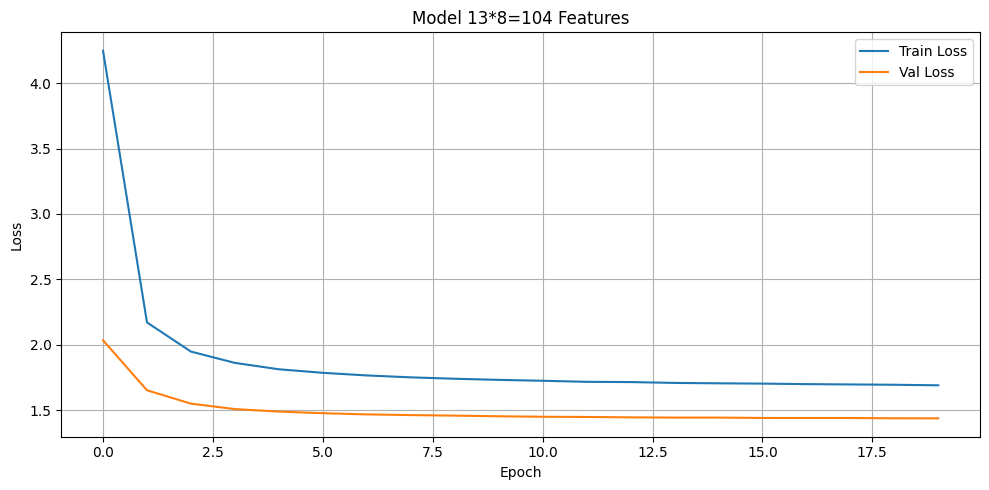

In [143]:
model=TimeSeriesTransformer(input_dim=features.shape[2]).to(device)
print(f"Using device: {device}")

print("Model Parameters:", sum(p.numel() for p in model.parameters()))
# Use smaller learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ==================== TRAINING LOOP ====================

num_epochs = 20
best_loss = float('inf')

train_losses = []
val_losses = []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    
    train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')

    for _, features, transformed_target,_ in train_bar:
        # Move to device
        features = features.to(device)
        transformed_target = transformed_target.to(device)
        
        # Train Market Model
        optimizer.zero_grad()
        output, _ = model(features)
        loss = criterion(output, transformed_target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()

        train_bar.set_postfix({
            'loss': loss.item()
        })
        
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)
    
    # Validation phase
    model.eval()        
    val_loss = 0
    

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')

        for _, features, transformed_target,_ in val_bar:
            features = features.to(device)
            transformed_target = transformed_target.to(device)

            output,_ = model(features)
            
            loss = criterion(output, transformed_target)

            val_bar.set_postfix({
                'loss': loss.item()
            })
            val_loss += loss.item()
            
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    
    # Update schedulers
    scheduler.step(avg_val)
    
    # Save best models
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save(model.state_dict(), 'New_transformer_model.pth')
        print(f"  ✓ Saved best model (val_loss: {avg_val:.6f})")
  
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train : {avg_train:.6f}")
    print(f"  Val  : {avg_val:.6f}")
    print(f"  LR  : {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\nTraining completed!")

# ==================== PLOT TRAINING CURVES ====================

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 13*8=104 Features')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('new_training_curves.png')
plt.show()


In [161]:
class Head(nn.Module):
    def __init__(
        self,
        dim: int = 18,
        hidden_dim: int = 64,
        dropout: float = 0.1
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)  # (B, 1) → RAW LOGITS

In [168]:
timeseries_model = TimeSeriesTransformer(input_dim=features.shape[2]).to(device)
timeseries_model.load_state_dict(
    torch.load('New_transformer_model.pth', map_location=device)
)
head_model = Head(dim=336, hidden_dim=320).to(device)
print("Head Model Parameters:", sum(p.numel() for p in head_model.parameters()))
print("Timeseries Model Parameters:", sum(p.numel() for p in timeseries_model.parameters()))


Head Model Parameters: 160033
Timeseries Model Parameters: 426152



Starting training...


Epoch 1/5 [Train]:   0%|          | 0/1114 [00:00<?, ?it/s]/tmp/ipykernel_10417/3406020727.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temp = torch.tensor(temp, dtype=torch.float32).to(device)
Epoch 1/5 [Val]:   0%|          | 0/279 [00:00<?, ?it/s]/tmp/ipykernel_10417/3406020727.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temp = torch.tensor(temp, dtype=torch.float32).to(device)
Epoch 1/5 [Val]: 100%|██████████| 279/279 [04:19<00:00,  1.08it/s, loss=3.97e-6] 


  ✓ Saved best model (val_loss: 0.092361)

Epoch 1/5
  Train : 0.120793
  Val   : 0.092361
  LR    : 0.000100
------------------------------------------------------------


Epoch 2/5 [Val]: 100%|██████████| 279/279 [04:13<00:00,  1.10it/s, loss=2.81e-6] 



Epoch 2/5
  Train : 0.090286
  Val   : 0.092652
  LR    : 0.000100
------------------------------------------------------------


...

  ✓ Saved best model (val_loss: 0.091898)

Epoch 3/5
  Train : 0.089396
  Val   : 0.091898
  LR    : 0.000100
------------------------------------------------------------


Epoch 4/5 [Val]: 100%|██████████| 279/279 [04:10<00:00,  1.11it/s, loss=0]       



Epoch 4/5
  Train : 0.088854
  Val   : 0.092281
  LR    : 0.000100
------------------------------------------------------------


Epoch 5/5 [Val]: 100%|██████████| 279/279 [04:02<00:00,  1.15it/s, loss=0]       

  ✓ Saved best model (val_loss: 0.091445)

Epoch 5/5
  Train : 0.088772
  Val   : 0.091445
  LR    : 0.000100
------------------------------------------------------------

Training completed!


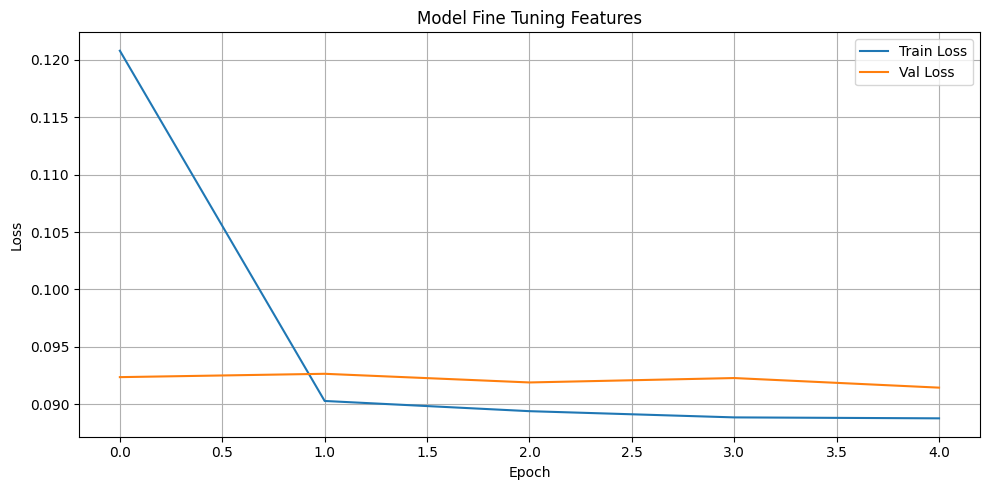

In [169]:

# ==================== OPTIMIZERS & LOSS ====================

# Use smaller learning rate
optimizer = torch.optim.Adam([
        {'params': head_model.parameters(), 'lr': 0.0001},
        {'params': timeseries_model.parameters(), 'lr': 0.0001 * 0.1},  # Lower LR for pretrained
])

criterion = nn.BCEWithLogitsLoss()
# ==================== TRAINING LOOP ====================

num_epochs = 5
best_loss = float('inf')

train_losses = []
val_losses = []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training phase
    timeseries_model.train()
    head_model.train()
    
    train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    
    for target, features, transformed_target,_ in train_bar:
        # Move to device
        features = features.to(device)
        target = target.to(device)
        transformed_target = transformed_target.to(device)
        
        # Train Market Model
        optimizer.zero_grad()
        output, temp = timeseries_model(features)
        temp = torch.tensor(temp, dtype=torch.float32).to(device)
        fusion = torch.cat([output, transformed_target, temp], dim=-1)
        fusion = fusion.to(device)
        output = head_model(fusion)
        output = output.squeeze(-1)  # Add this line to remove the extra dimension
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(head_model.parameters()) + list(timeseries_model.parameters()), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
        train_bar.set_postfix({
            'loss': loss.item()
        })
    
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)
    
    # Validation phase
    timeseries_model.eval()
    head_model.eval()
    val_loss = 0
    

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for target, features, transformed_target,_ in val_bar:
            features = features.to(device)
            target = target.to(device)
            transformed_target = transformed_target.to(device)

            output, temp = timeseries_model(features)
            temp = torch.tensor(temp, dtype=torch.float32).to(device)
            fusion = torch.cat([output, transformed_target, temp], dim=-1)
            fusion = fusion.to(device)

            output = head_model(fusion)
            output = output.squeeze(-1)  # Add this line to remove the extra dimension
            loss = criterion(output, target)
            
            val_loss += loss.item()
            
            val_bar.set_postfix({
                'loss': loss.item()
            })
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    
    # Update schedulers
    scheduler.step(avg_val)
    
    # Save best models
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save({ 'head_model': head_model.state_dict(), 'timeseries_model': timeseries_model.state_dict() }, 'new_finetuned_with_head.pth')
        print(f"  ✓ Saved best model (val_loss: {avg_val:.6f})")
  
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train : {avg_train:.6f}")
    print(f"  Val   : {avg_val:.6f}")
    print(f"  LR    : {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\nTraining completed!")

# ==================== PLOT TRAINING CURVES ====================

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Fine Tuning Features')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('new_training_curves_after_fine_tuning.png')
plt.show()


In [170]:
from sklearn.metrics import roc_auc_score,accuracy_score,precision_score,recall_score,f1_score,classification_report

In [172]:
timeseries_model.load_state_dict(torch.load('new_finetuned_with_head.pth')['timeseries_model'])
head_model.load_state_dict(torch.load('new_finetuned_with_head.pth')['head_model'])

y_pred_list=[]
y_true_list=[]
i=0

for target, features, transformed_target,_ in val_loader:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)

    output,temp = timeseries_model(features)
    temp = torch.tensor(temp, dtype=torch.float32).to(device)
    fusion = torch.cat([output, transformed_target, temp], dim=-1)

    y_pred = head_model(fusion)

    y_pred_list.append(y_pred.detach().cpu().numpy())
    y_true_list.append(target.cpu().numpy().reshape(-1))
    if i%10==0:
        print(i)
    i+=1


/tmp/ipykernel_10417/2833540606.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temp = torch.tensor(temp, dtype=torch.float32).to(device)


0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270


In [174]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    matthews_corrcoef, balanced_accuracy_score
)

# Concatenate predictions
y_pred = np.concatenate(y_pred_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)

# Ensure 1D arrays
y_pred = y_pred.reshape(-1)
y_true = y_true.reshape(-1)

# Apply sigmoid to logits
y_pred_prob = 1 / (1 + np.exp(-y_pred))

# Convert to binary labels
y_pred_label = (y_pred_prob > 0.5).astype(int)

# Calculate metrics
print("="*50)
print("BINARY CLASSIFICATION METRICS")
print("="*50)

# Basic metrics
print(f"Accuracy:  {accuracy_score(y_true, y_pred_label):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_label, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_label, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_true, y_pred_label, zero_division=0):.4f}")

# Additional useful metrics
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred_label):.4f}")
print(f"MCC: {matthews_corrcoef(y_true, y_pred_label):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_true, y_pred_prob):.4f}")

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_label).ravel()
print(f"\nConfusion Matrix:")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

# Additional metrics from confusion matrix
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"Specificity: {specificity:.4f}")
print(f"False Positive Rate: {1-specificity:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred_label, target_names=['Class 0', 'Class 1']))

BINARY CLASSIFICATION METRICS
Accuracy:  0.9704
Precision: 0.9739
Recall:    0.8162
F1 Score:  0.8881
Balanced Accuracy: 0.9063
MCC: 0.8758
ROC-AUC: 0.9736

Confusion Matrix:
TN: 15191, FP: 56, FN: 471, TP: 2092
Specificity: 0.9963
False Positive Rate: 0.0037

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.97      1.00      0.98     15247
     Class 1       0.97      0.82      0.89      2563

    accuracy                           0.97     17810
   macro avg       0.97      0.91      0.94     17810
weighted avg       0.97      0.97      0.97     17810



In [176]:
train_temp.to_csv("../dataset/train_time.csv",index=False)
test_temp.to_csv("../dataset/test_time.csv",index=False)
val_temp.to_csv("../dataset/val_temp.csv",index=False)

In [177]:
timeseries_model.load_state_dict(torch.load('new_finetuned_with_head.pth')['timeseries_model'])
head_model.load_state_dict(torch.load('new_finetuned_with_head.pth')['head_model'])

y_pred_list=[]
y_true_list=[]
i=0

for target, features, transformed_target,_ in test_loader:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)

    output,temp = timeseries_model(features)
    temp = torch.tensor(temp, dtype=torch.float32).to(device)
    fusion = torch.cat([output, transformed_target, temp], dim=-1)

    y_pred = head_model(fusion)

    y_pred_list.append(y_pred.detach().cpu().numpy())
    y_true_list.append(target.cpu().numpy().reshape(-1))
    if i%10==0:
        print(i)
    i+=1


/tmp/ipykernel_10417/4199068442.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temp = torch.tensor(temp, dtype=torch.float32).to(device)


0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340


In [178]:
# Concatenate predictions
y_pred = np.concatenate(y_pred_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)

# Ensure 1D arrays
y_pred = y_pred.reshape(-1)
y_true = y_true.reshape(-1)

# Apply sigmoid to logits
y_pred_prob = 1 / (1 + np.exp(-y_pred))

# Convert to binary labels
y_pred_label = (y_pred_prob > 0.5).astype(int)

# Calculate metrics
print("="*50)
print("BINARY CLASSIFICATION METRICS")
print("="*50)

# Basic metrics
print(f"Accuracy:  {accuracy_score(y_true, y_pred_label):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_label, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_label, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_true, y_pred_label, zero_division=0):.4f}")

# Additional useful metrics
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred_label):.4f}")
print(f"MCC: {matthews_corrcoef(y_true, y_pred_label):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_true, y_pred_prob):.4f}")

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_label).ravel()
print(f"\nConfusion Matrix:")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

# Additional metrics from confusion matrix
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"Specificity: {specificity:.4f}")
print(f"False Positive Rate: {1-specificity:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred_label, target_names=['Class 0', 'Class 1']))

BINARY CLASSIFICATION METRICS
Accuracy:  0.9752
Precision: 0.9803
Recall:    0.8435
F1 Score:  0.9068
Balanced Accuracy: 0.9204
MCC: 0.8959
ROC-AUC: 0.9781

Confusion Matrix:
TN: 19029, FP: 54, FN: 498, TP: 2685
Specificity: 0.9972
False Positive Rate: 0.0028

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.97      1.00      0.99     19083
     Class 1       0.98      0.84      0.91      3183

    accuracy                           0.98     22266
   macro avg       0.98      0.92      0.95     22266
weighted avg       0.98      0.98      0.97     22266



In [179]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class CNNBlock(nn.Module):
    """CNN block for binary classification after transformer output"""
    def __init__(self, in_channels, hidden_channels=256, dropout=0.1):
        super(CNNBlock, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # First conv block
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            
            # Second conv block
            nn.Conv2d(hidden_channels, hidden_channels // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels // 2),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            
            # Third conv block
            nn.Conv2d(hidden_channels // 2, hidden_channels // 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels // 4),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )
        
        # Global average pooling and classification head
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels // 4, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1)  # Binary classification output
        )
        
    def forward(self, x):
        # x shape: (batch, channels=nhead*num_layers, seq_len, d_model)
        x = self.conv_layers(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        cnn_features = x  # Save features for potential use
        x = self.classifier(x)
        return x, cnn_features


class ImageAnalysis(nn.Module):

    def __init__(self, input_dim=14, d_model=128, nhead=8, num_layers=3, 
                 dim_feedforward=256, dropout=0.1, cnn_hidden=256):
        super(ImageAnalysis, self).__init__()

        self.d_model = d_model
        self.nhead = nhead
        self.num_layers = num_layers

        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # Transformer encoder
        self.encoder_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                batch_first=True
            )
            for _ in range(num_layers)
        ])

        self.to_image = nn.Linear(d_model, nhead * d_model)
        
        # CNN block for binary classification
        # Input channels = nhead * num_layers (concatenated across transformer layers)
        self.cnn_block = CNNBlock(
            in_channels=nhead * num_layers,  # FIXED: multiplied by num_layers
            hidden_channels=cnn_hidden,
            dropout=dropout
        )

    def forward(self, x):
        batch_size, seq_len, input_dim = x.shape

        images=[]

        x = x.view(batch_size, seq_len, input_dim)

        # Project input
        x = self.input_projection(x) * math.sqrt(self.d_model)

        # Add positional encoding
        x = self.pos_encoder(x)

        # Apply transformer
        for layer_idx, encoder_layer in enumerate(self.encoder_layers):
            x = encoder_layer(x)

            image = self.to_image(x)  # (batch, seq_len, nhead*d_model)
            image = image.view(batch_size, seq_len, self.nhead, self.d_model)
            image = image.permute(0, 2, 1, 3)  # (batch, nhead, seq_len, d_model)
            images.append(image)

        # Concatenate all transformer layer outputs
        # Shape: (batch, nhead * num_layers, seq_len, d_model)
        result = torch.cat(images, dim=1)
        
        # Apply CNN block for binary classification
        cnn_output, cnn_features = self.cnn_block(result)
        
        final_output = torch.sigmoid(cnn_output)
        
        return final_output, cnn_features

In [180]:
model=ImageAnalysis(
    input_dim=features.shape[2],
    d_model=64,        # Reduced
    nhead=2,           # Reduced
    num_layers=2,      # Reduced
    dim_feedforward=64, # Reduced
    dropout=0.3, 
    cnn_hidden=128
).to(device)


Model Parameters: 167265

Starting training...


Epoch 1/3 [Val]: 100%|██████████| 279/279 [04:30<00:00,  1.03it/s, loss=0.694]


  ✓ Saved best market model (val_loss: 0.669907)

Epoch 1/3
  Train -: 0.705466
  Val   -: 0.669907
  LR    -: 0.000100
------------------------------------------------------------


Epoch 2/3 [Val]: 100%|██████████| 279/279 [04:16<00:00,  1.09it/s, loss=0.693]


  ✓ Saved best market model (val_loss: 0.660611)

Epoch 2/3
  Train -: 0.665430
  Val   -: 0.660611
  LR    -: 0.000100
------------------------------------------------------------


Epoch 3/3 [Val]: 100%|██████████| 279/279 [04:18<00:00,  1.08it/s, loss=0.693]

  ✓ Saved best market model (val_loss: 0.654517)

Epoch 3/3
  Train -: 0.657212
  Val   -: 0.654517
  LR    -: 0.000100
------------------------------------------------------------

Training completed!


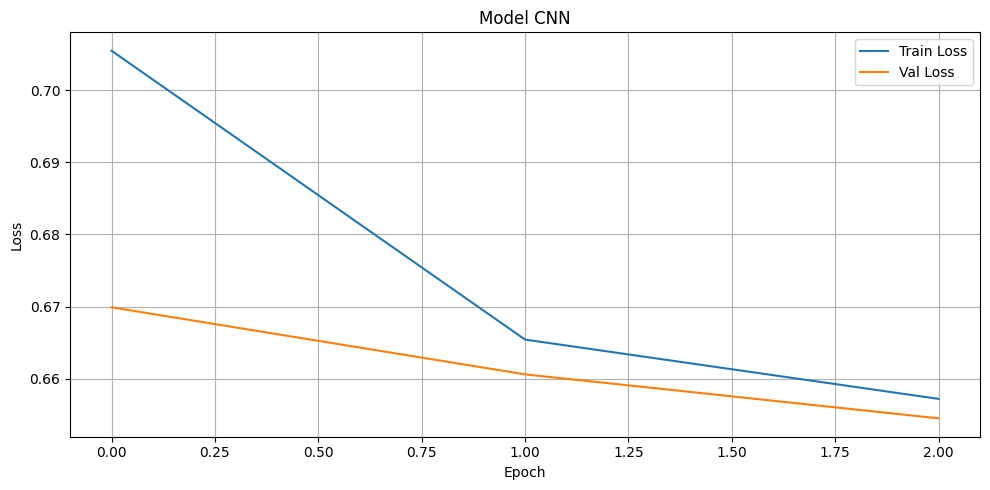

In [181]:

print("Model Parameters:", sum(p.numel() for p in model.parameters()))

# ==================== OPTIMIZERS & LOSS ====================

# Use smaller learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

criterion = nn.BCEWithLogitsLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ==================== TRAINING LOOP ====================

num_epochs = 3
best_loss = float('inf')

train_losses = []
val_losses = []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    
    train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    
    for target, features, transformed_target,_ in train_bar:
        # Move to device
        features = features.to(device)
        transformed_target = transformed_target.to(device)
        target = target.to(device)
        
        input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)  # (batch, seq_len, num_features + target_dim)
        input = input.to(device)
        # Train Market Model
        optimizer.zero_grad()
        output, _ = model(input)
        output = output.squeeze(-1)  # Add this line to remove the extra dimension

        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
        train_bar.set_postfix({
            'loss': loss.item()
        })
    
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)
    
    model.eval()        
    val_loss = 0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for target, features, transformed_target,_ in val_bar:
            features = features.to(device)
            transformed_target = transformed_target.to(device)
            target = target.to(device)

            input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)  # (batch, seq_len, num_features + target_dim)
            input = input.to(device)

            output,_ = model(input)
            output = output.squeeze(-1)  # Add this line to remove the extra dimension

            loss = criterion(output, target)
            
            val_loss += loss.item()
            
            val_bar.set_postfix({
                'loss': loss.item()
            })
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    
    # Update schedulers
    scheduler.step(avg_val)
    
    # Save best models
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save(model.state_dict(), 'best_cnn_model.pth')
        print(f"  ✓ Saved best market model (val_loss: {avg_val:.6f})")
  
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train -: {avg_train:.6f}")
    print(f"  Val   -: {avg_val:.6f}")
    print(f"  LR    -: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\nTraining completed!")

# ==================== PLOT TRAINING CURVES ====================

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model CNN')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves CNN.png')
plt.show()


In [182]:
model.load_state_dict(torch.load('best_cnn_model.pth'))


<All keys matched successfully>

In [184]:
y_pred_list=[]
y_true_list=[]
i=0

for target, features, transformed_target,_ in val_loader:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)
    input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)  # (batch, seq_len, num_features + target_dim)
    input = input.to(device)
    y_pred,_ = model(input)

    y_pred_list.append(y_pred.detach().cpu().numpy())
    y_true_list.append(target.cpu().numpy().reshape(-1))
    if i%10==0:
        print(i)

    i+=1

y_pred = np.concatenate(y_pred_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)


0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270


In [185]:
# Ensure 1D arrays
y_pred = y_pred.reshape(-1)
y_true = y_true.reshape(-1)

# Apply sigmoid to logits
y_pred_prob = 1 / (1 + np.exp(-y_pred))

# Convert to binary labels
y_pred_label = (y_pred_prob > 0.5).astype(int)

# Calculate metrics
print("="*50)
print("BINARY CLASSIFICATION METRICS")
print("="*50)

# Basic metrics
print(f"Accuracy:  {accuracy_score(y_true, y_pred_label):.4f}")
print(f"Binary Precision: {precision_score(y_true, y_pred_label, zero_division=0,average='binary'):.4f}")
print(f"Binary Recall:    {recall_score(y_true, y_pred_label, zero_division=0,average='binary'):.4f}")
print(f"Binary F1 Score:  {f1_score(y_true, y_pred_label, zero_division=0, average='binary'):.4f}")

# Additional useful metrics
print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred_label):.4f}")
print(f"MCC: {matthews_corrcoef(y_true, y_pred_label):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_true, y_pred_prob):.4f}")

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_label).ravel()
print(f"\nConfusion Matrix:")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

# Additional metrics from confusion matrix
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"Specificity: {specificity:.4f}")
print(f"False Positive Rate: {1-specificity:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred_label, target_names=['Class 0', 'Class 1']))

BINARY CLASSIFICATION METRICS
Accuracy:  0.1439
Binary Precision: 0.1439
Binary Recall:    1.0000
Binary F1 Score:  0.2516
Balanced Accuracy: 0.5000
MCC: 0.0000
ROC-AUC: 0.8800

Confusion Matrix:
TN: 0, FP: 15247, FN: 0, TP: 2563
Specificity: 0.0000
False Positive Rate: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00     15247
     Class 1       0.14      1.00      0.25      2563

    accuracy                           0.14     17810
   macro avg       0.07      0.50      0.13     17810
weighted avg       0.02      0.14      0.04     17810



/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aryansharma/AIML_Projects/ai_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,